# 24 — BMI × Activity × Physiological Metrics (Weight / BP / ECG)

**Purpose**: Stratify on BMI and examine relationships between physical activity,
body weight/composition metrics, blood pressure, and cardiac ECG parameters.

**Key questions**:
- How does BMI distribute across disease severity (study groups)?
- Does activity level predict BMI, and is this relationship modified by disease severity?
- Does BMI predict blood pressure and ECG (QTc) independently of disease severity?
- Which physiological metrics are most strongly correlated with activity level?

**Inputs**:
- Azure: `measurement.csv` (BMI, weight, height, BP, HR, waist circumference)
- Azure: `wearable_activity_monitor/manifest.tsv`
- Google Drive: `features_with_cluster.csv`
- Azure: `cardiac_ecg/manifest.tsv` (QTc, Rate — or already in features via NB14)

**Output**: `23_bmi_activity_physiological_summary.csv`

**Runtime**: Designed for Cursor IDE with Colab kernel, or Google Colab directly.

In [1]:
# ── 1. Environment Setup ───────────────────────────────────────────
import subprocess, sys

packages = ['azure-storage-blob', 'scipy', 'seaborn', 'statsmodels']
for pkg in packages:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'],
                   capture_output=True, text=True)

import os, getpass, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from io import StringIO
from scipy import stats
from itertools import combinations

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
pd.set_option('display.float_format', '{:.3f}'.format)

STUDY_GROUP_ORDER = ['Healthy', 'Pre-DM', 'Oral Med', 'Insulin']
STUDY_GROUP_MAP   = {0: 'Healthy', 1: 'Pre-DM', 2: 'Oral Med', 3: 'Insulin'}
STUDY_GROUP_PAL   = dict(zip(STUDY_GROUP_ORDER, sns.color_palette('Set2', 4)))

STUDY_ID       = '00b62456-0b93-4975-a992-42ba6a50ed5c'
CONTAINER_NAME = 'aireadi-raw'

print('Environment ready.')

Environment ready.


In [2]:
# ── 2. Google Drive Mount ──────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive', force_remount=False)
out_dir = Path('/content/drive/MyDrive/ORGANIZATIONS/ucsftech_outputs')
out_dir.mkdir(parents=True, exist_ok=True)
print(f'Output directory: {out_dir}')

Mounted at /content/drive
Output directory: /content/drive/MyDrive/ORGANIZATIONS/ucsftech_outputs


In [3]:
# ── 3. Azure Connection ────────────────────────────────────────────
from azure.storage.blob import BlobServiceClient

IN_COLAB = os.path.exists('/content')
if IN_COLAB:
    print('Paste your Azure CONNECTION_STRING when prompted:')
    CONNECTION_STRING = getpass.getpass('CONNECTION_STRING: ')
else:
    repo_root = os.path.abspath('..')
    if repo_root not in sys.path:
        sys.path.insert(0, repo_root)
    from config.azure_config import CONNECTION_STRING, CONTAINER_NAME

blob_svc  = BlobServiceClient.from_connection_string(CONNECTION_STRING)
container = blob_svc.get_container_client(CONTAINER_NAME)

def load_blob_csv(blob_path, sep=',', **kwargs):
    bc   = container.get_blob_client(blob_path)
    data = bc.download_blob().readall().decode('utf-8')
    return pd.read_csv(StringIO(data), sep=sep, low_memory=False, **kwargs)

print('Azure connection established.')

Paste your Azure CONNECTION_STRING when prompted:
Azure connection established.


In [4]:
# ── 4. Load Features & Extract Physiological Measurements ─────────
features = pd.read_csv(out_dir / 'features_with_cluster.csv')
features['person_id'] = features['person_id'].astype(str)

if 'study_group_label' not in features.columns:
    features['study_group_label'] = features['study_group_code'].map(STUDY_GROUP_MAP)
features['study_group_label'] = pd.Categorical(
    features['study_group_label'], categories=STUDY_GROUP_ORDER, ordered=True)

print('Loading measurement.csv from Azure (~30–60 seconds)...')
meas = load_blob_csv(f'{STUDY_ID}/dataset/clinical_data/measurement.csv')
print(f'measurement.csv: {meas.shape}')

# Confirmed fields (from NB13 exploration):
PHYS_FIELDS = {
    'bmi_vsorres':       'bmi',
    'weight_vsorres':    'weight_kg',
    'height_vsorres':    'height_cm',
    'waist_vsorres':     'waist_cm',
    'hip_vsorres':       'hip_cm',
    'bp1_sysbp_vsorres': 'systolic_bp',
    'bp1_diabp_vsorres': 'diastolic_bp',
    'bp2_sysbp_vsorres': 'systolic_bp_2',
    'bp2_diabp_vsorres': 'diastolic_bp_2',
    'pulse_vsorres':     'pulse_bpm',
}

# Extract each measurement per person (mean if multiple reads)
meas['item_key'] = (meas['measurement_source_value']
                    .astype(str)
                    .str.split(',', n=1).str[0]
                    .str.strip().str.lower())

phys_frames = []
for raw_key, out_col in PHYS_FIELDS.items():
    sub = meas[meas['item_key'] == raw_key][['person_id', 'value_as_number']].copy()
    sub = sub.dropna(subset=['value_as_number'])
    if sub.empty:
        print(f'  No data for {raw_key}')
        continue
    per_person = sub.groupby('person_id')['value_as_number'].mean().reset_index()
    per_person.columns = ['person_id', out_col]
    per_person['person_id'] = per_person['person_id'].astype(str)
    phys_frames.append(per_person)
    print(f'  {raw_key} → {out_col}: {len(per_person):,} participants')

# Merge all physiological measurements
phys_df = phys_frames[0]
for f in phys_frames[1:]:
    phys_df = phys_df.merge(f, on='person_id', how='outer')

print(f'\nPhysiological dataset: {phys_df.shape}')

Loading measurement.csv from Azure (~30–60 seconds)...
measurement.csv: (242279, 26)
  bmi_vsorres → bmi: 2,273 participants
  weight_vsorres → weight_kg: 2,274 participants
  height_vsorres → height_cm: 2,273 participants
  waist_vsorres → waist_cm: 2,269 participants
  hip_vsorres → hip_cm: 2,268 participants
  bp1_sysbp_vsorres → systolic_bp: 2,278 participants
  bp1_diabp_vsorres → diastolic_bp: 2,278 participants
  bp2_sysbp_vsorres → systolic_bp_2: 2,273 participants
  bp2_diabp_vsorres → diastolic_bp_2: 2,273 participants
  pulse_vsorres → pulse_bpm: 2,278 participants

Physiological dataset: (2280, 11)


In [5]:
# ── 4b. Load activity manifest + ECG manifest ─────────────────────
print('Loading activity manifest...')
act_manifest = load_blob_csv(
    f'{STUDY_ID}/dataset/wearable_activity_monitor/manifest.tsv', sep='\t')
act_manifest['person_id'] = act_manifest['person_id'].astype(str)
ACT_COLS = ['average_daily_activity', 'average_active_calories_kcal',
            'average_heartrate_bpm', 'average_oxygen_saturation_pct']
ACT_COLS = [c for c in ACT_COLS if c in act_manifest.columns]

print('Loading ECG manifest...')
ecg_manifest = load_blob_csv(
    f'{STUDY_ID}/dataset/cardiac_ecg/manifest.tsv', sep='\t')
ecg_manifest['person_id'] = ecg_manifest['person_id'].astype(str)
ECG_COLS = ['Rate', 'QTc', 'PR', 'QRSD', 'QT']
ECG_COLS = [c for c in ECG_COLS if c in ecg_manifest.columns]

# Merge everything
df = (features
      .merge(phys_df, on='person_id', how='left')
      .merge(act_manifest[['person_id'] + ACT_COLS], on='person_id', how='left')
      .merge(ecg_manifest[['person_id'] + ECG_COLS], on='person_id', how='left'))

# Average the two BP readings if available
for bp in ['systolic_bp', 'diastolic_bp']:
    bp2 = f'{bp}_2'
    if bp in df.columns and bp2 in df.columns:
        df[f'{bp}_mean'] = df[[bp, bp2]].mean(axis=1)

print(f'\nFinal dataset: {df.shape}')
print(f'BMI coverage: {df["bmi"].notna().sum():,} / {len(df):,}')
print(df[['bmi', 'weight_kg', 'systolic_bp', 'diastolic_bp', 'pulse_bpm',
          'average_daily_activity', 'QTc', 'Rate']].describe().round(2))

Loading activity manifest...
Loading ECG manifest...

Final dataset: (2251, 43)
BMI coverage: 2,247 / 2,251
           bmi  weight_kg  systolic_bp  diastolic_bp  pulse_bpm  \
count 2247.000   2248.000     2249.000      2249.000   2249.000   
mean    30.110     83.860      128.510        76.900     71.410   
std      7.470     22.350       17.110        10.170     11.830   
min     15.950     34.900       71.000        41.000     36.000   
25%     24.950     67.880      117.000        70.000     63.000   
50%     28.440     80.600      128.000        77.000     71.000   
75%     33.680     95.930      139.000        83.000     79.000   
max     95.240    215.800      194.000       132.000    123.000   

       average_daily_activity      QTc     Rate  
count                2128.000 2226.000 2226.000  
mean                 6167.470  429.730   66.420  
std                  3840.410   28.040   10.960  
min                     0.000  351.000   34.000  
25%                  3798.400  412.000

## Section 2: BMI Distribution by Study Group

=== BMI Category Prevalence by Study Group ===

bmi_category       Underweight (<18.5)  Normal (18.5–25)  Overweight (25–30)  Obese (≥30)
study_group_label                                                                        
Healthy                          1.800            31.800              35.400       30.900
Pre-DM                           0.900            27.800              34.000       37.300
Oral Med                         0.000            19.000              31.300       49.600
Insulin                          0.800            10.800              28.300       60.200


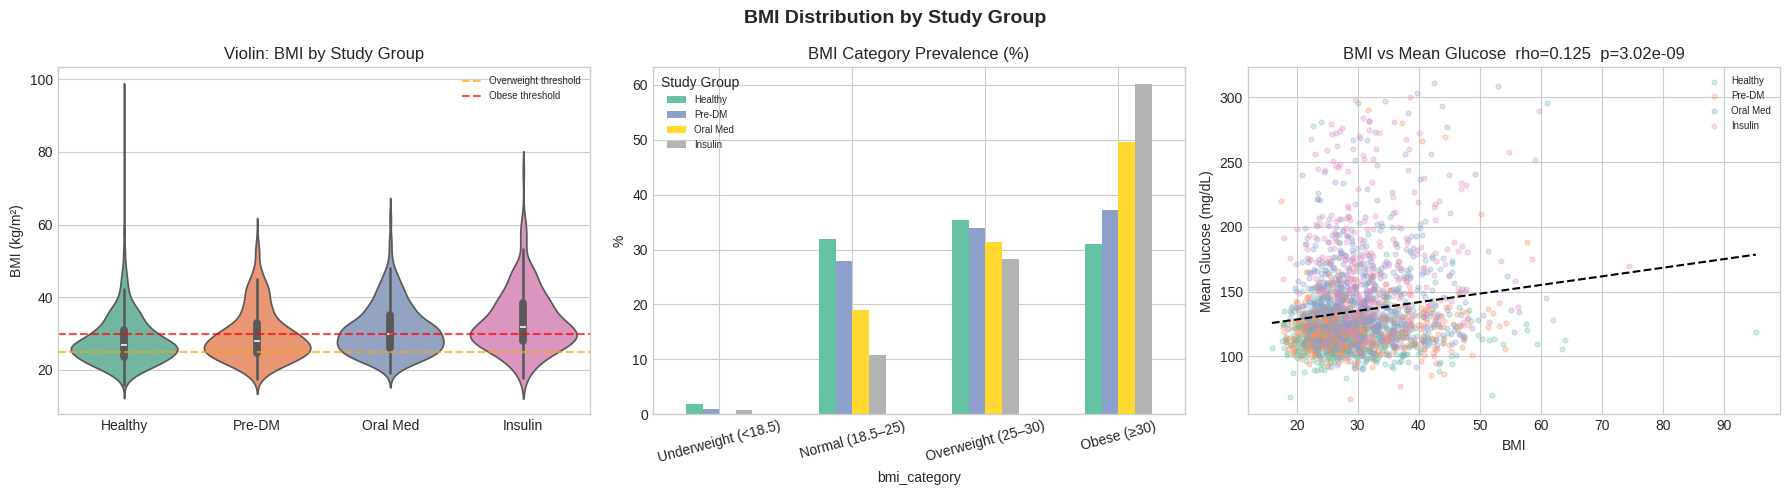


Kruskal-Wallis BMI: H=136.25  p=2.4351e-29


In [6]:
# ── 2a. BMI category distribution ─────────────────────────────────
df['bmi_category'] = pd.cut(
    df['bmi'],
    bins=[0, 18.5, 25, 30, np.inf],
    labels=['Underweight (<18.5)', 'Normal (18.5–25)', 'Overweight (25–30)', 'Obese (≥30)'],
    right=False)
BMI_CAT_ORDER = ['Underweight (<18.5)', 'Normal (18.5–25)', 'Overweight (25–30)', 'Obese (≥30)']

print('=== BMI Category Prevalence by Study Group ===\n')
bmi_prev = (df.dropna(subset=['bmi_category', 'study_group_label'])
             .groupby(['study_group_label', 'bmi_category'], observed=True)
             .size().unstack(fill_value=0))
bmi_pct  = bmi_prev.div(bmi_prev.sum(axis=1), axis=0) * 100
print(bmi_pct.round(1).to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('BMI Distribution by Study Group', fontsize=14, fontweight='bold')

sns.violinplot(data=df.dropna(subset=['bmi', 'study_group_label']),
               x='study_group_label', y='bmi',
               order=STUDY_GROUP_ORDER, palette='Set2', inner='box', ax=axes[0])
axes[0].axhline(25, color='orange', linestyle='--', alpha=0.7, label='Overweight threshold')
axes[0].axhline(30, color='red',    linestyle='--', alpha=0.7, label='Obese threshold')
axes[0].set_title('Violin: BMI by Study Group'); axes[0].set_xlabel('')
axes[0].set_ylabel('BMI (kg/m²)'); axes[0].legend(fontsize=7)

bmi_pct.T.plot(kind='bar', ax=axes[1], colormap='Set2')
axes[1].set_title('BMI Category Prevalence (%)'); axes[1].set_ylabel('%')
axes[1].tick_params(axis='x', rotation=15); axes[1].legend(title='Study Group', fontsize=7)

# BMI vs mean_glucose scatter
sub_bmi = df[['bmi', 'mean_glucose', 'study_group_label']].dropna()
for grp in STUDY_GROUP_ORDER:
    s = sub_bmi[sub_bmi['study_group_label'] == grp]
    axes[2].scatter(s['bmi'], s['mean_glucose'], alpha=0.3, s=12,
                    color=STUDY_GROUP_PAL[grp], label=grp)
m, b, *_ = stats.linregress(sub_bmi['bmi'], sub_bmi['mean_glucose'])
xs = np.linspace(sub_bmi['bmi'].min(), sub_bmi['bmi'].max(), 100)
axes[2].plot(xs, m*xs + b, 'k--', linewidth=1.5)
rho, p = stats.spearmanr(sub_bmi['bmi'], sub_bmi['mean_glucose'])
axes[2].set_title(f'BMI vs Mean Glucose  rho={rho:.3f}  p={p:.2e}')
axes[2].set_xlabel('BMI'); axes[2].set_ylabel('Mean Glucose (mg/dL)')
axes[2].legend(fontsize=7)

plt.tight_layout(); plt.show()

# Kruskal-Wallis BMI across study groups
grp_bmi = [df[df['study_group_label'] == g]['bmi'].dropna().values for g in STUDY_GROUP_ORDER]
H, p_kw = stats.kruskal(*[g for g in grp_bmi if len(g) > 0])
print(f'\nKruskal-Wallis BMI: H={H:.2f}  p={p_kw:.4e}')

## Section 3: BMI Quartile Stratification × Activity

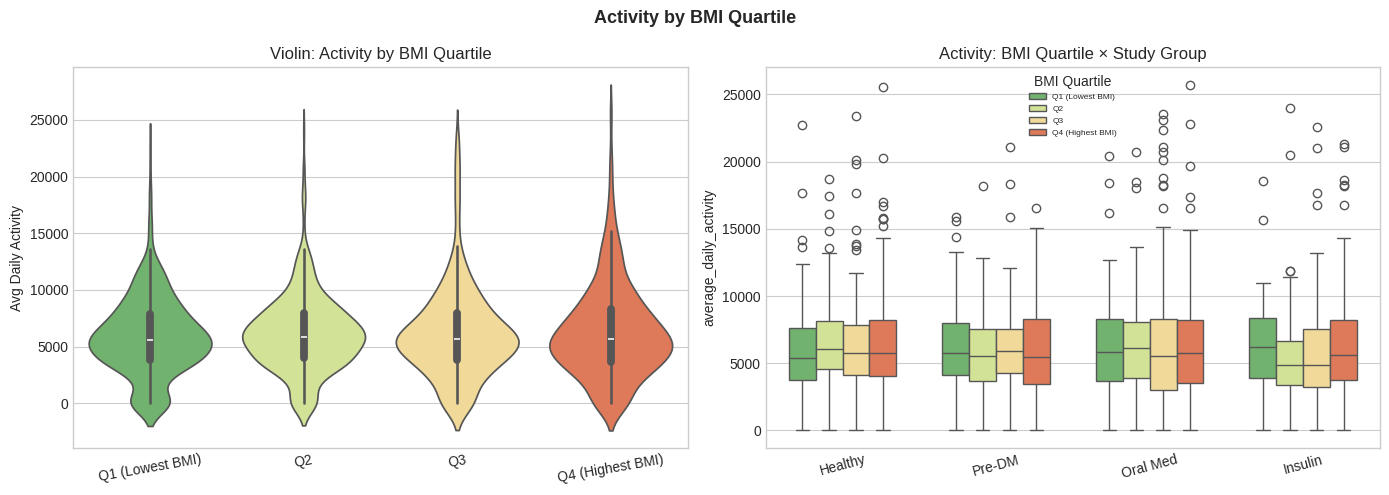


=== Spearman: BMI vs Activity × Study Group ===
  All         : rho=+0.006  p=7.9091e-01  n=2,124  ns
  Healthy     : rho=+0.066  p=7.9332e-02  n=718  ns
  Pre-DM      : rho=-0.023  p=6.0322e-01  n=527  ns
  Oral Med    : rho=+0.001  p=9.7954e-01  n=640  ns
  Insulin     : rho=+0.009  p=8.8545e-01  n=239  ns


In [7]:
# ── 3a. BMI quartiles × activity ──────────────────────────────────
df_bmi = df.dropna(subset=['bmi']).copy()
df_bmi['bmi_quartile'] = pd.qcut(
    df_bmi['bmi'], q=4, labels=['Q1 (Lowest BMI)', 'Q2', 'Q3', 'Q4 (Highest BMI)'])
BMI_Q_ORDER = ['Q1 (Lowest BMI)', 'Q2', 'Q3', 'Q4 (Highest BMI)']
BMI_Q_PAL   = dict(zip(BMI_Q_ORDER, sns.color_palette('RdYlGn_r', 4)))

ACT_COL = 'average_daily_activity'

if ACT_COL in df_bmi.columns:
    sub = df_bmi.dropna(subset=[ACT_COL, 'bmi_quartile'])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Activity by BMI Quartile', fontsize=13, fontweight='bold')

    sns.violinplot(data=sub, x='bmi_quartile', y=ACT_COL,
                   order=BMI_Q_ORDER, palette=BMI_Q_PAL, inner='box', ax=axes[0])
    axes[0].set_title('Violin: Activity by BMI Quartile'); axes[0].set_xlabel('')
    axes[0].set_ylabel('Avg Daily Activity'); axes[0].tick_params(axis='x', rotation=10)

    # Interaction: BMI quartile × study group
    sns.boxplot(data=sub, x='study_group_label', y=ACT_COL,
                hue='bmi_quartile',
                order=STUDY_GROUP_ORDER, hue_order=BMI_Q_ORDER,
                palette=BMI_Q_PAL, width=0.7, ax=axes[1])
    axes[1].set_title('Activity: BMI Quartile × Study Group'); axes[1].set_xlabel('')
    axes[1].tick_params(axis='x', rotation=15); axes[1].legend(title='BMI Quartile', fontsize=6)

    plt.tight_layout(); plt.show()

    # Spearman: BMI vs activity within each study group
    print('\n=== Spearman: BMI vs Activity × Study Group ===')
    for grp in ['All'] + STUDY_GROUP_ORDER:
        s = sub if grp == 'All' else sub[sub['study_group_label'] == grp]
        s2 = s[['bmi', ACT_COL]].dropna()
        if len(s2) < 20:
            continue
        rho, p = stats.spearmanr(s2['bmi'], s2[ACT_COL])
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        print(f'  {grp:<12}: rho={rho:+.3f}  p={p:.4e}  n={len(s2):,}  {sig}')

## Section 4: BMI × Blood Pressure

In [8]:
# ── 4a. Spearman: BMI vs BP within study groups ────────────────────
BP_COLS = [
    ('systolic_bp_mean' if 'systolic_bp_mean' in df.columns else 'systolic_bp', 'Systolic BP (mmHg)'),
    ('diastolic_bp_mean' if 'diastolic_bp_mean' in df.columns else 'diastolic_bp', 'Diastolic BP (mmHg)'),
    ('pulse_bpm', 'Pulse (bpm)'),
]
BP_COLS = [(c, l) for c, l in BP_COLS if c in df.columns]

print('=== Spearman: BMI vs Blood Pressure Metrics ===\n')
print(f'{"Study Group":<12}  {"BP Metric":<22}  {"rho":>8}  {"p":>12}  {"n":>6}  sig')
print('-' * 68)

bp_rows = []
for grp in ['All'] + STUDY_GROUP_ORDER:
    sub = df if grp == 'All' else df[df['study_group_label'] == grp]
    for col, label in BP_COLS:
        s2 = sub[['bmi', col]].dropna()
        if len(s2) < 20:
            continue
        rho, p = stats.spearmanr(s2['bmi'], s2[col])
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        print(f'{grp:<12}  {label:<22}  {rho:+8.4f}  {p:12.4e}  {len(s2):6d}  {sig}')
        bp_rows.append({'study_group': grp, 'bp_metric': col, 'rho': round(rho, 4),
                        'p': round(p, 6), 'n': len(s2), 'sig': sig})

=== Spearman: BMI vs Blood Pressure Metrics ===

Study Group   BP Metric                    rho             p       n  sig
--------------------------------------------------------------------
All           Systolic BP (mmHg)       +0.1658    2.7018e-15    2245  ***
All           Diastolic BP (mmHg)      +0.2163    3.6313e-25    2245  ***
All           Pulse (bpm)              +0.2237    7.2475e-27    2245  ***
Healthy       Systolic BP (mmHg)       +0.2088    6.3805e-09     759  ***
Healthy       Diastolic BP (mmHg)      +0.2210    7.4581e-10     759  ***
Healthy       Pulse (bpm)              +0.2066    9.2768e-09     759  ***
Pre-DM        Systolic BP (mmHg)       +0.1756    3.2902e-05     553  ***
Pre-DM        Diastolic BP (mmHg)      +0.2703    1.0284e-10     553  ***
Pre-DM        Pulse (bpm)              +0.1600    1.5839e-04     553  ***
Oral Med      Systolic BP (mmHg)       +0.1360    3.6794e-04     682  ***
Oral Med      Diastolic BP (mmHg)      +0.2554    1.2821e-11     682

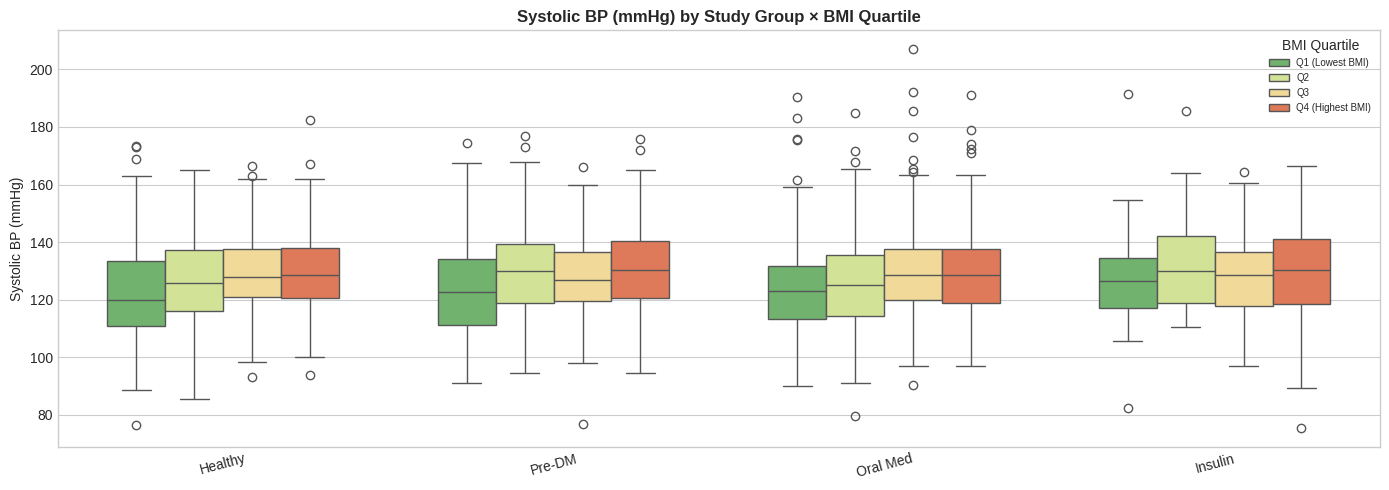

In [9]:
# ── 4b. BP by BMI quartile × study group ──────────────────────────
if BP_COLS and 'bmi_quartile' in df_bmi.columns:
    bp_col = BP_COLS[0][0]  # systolic BP
    bp_label = BP_COLS[0][1]

    fig, ax = plt.subplots(figsize=(14, 5))
    sub = df_bmi.dropna(subset=[bp_col, 'bmi_quartile', 'study_group_label'])
    sns.boxplot(data=sub, x='study_group_label', y=bp_col,
                hue='bmi_quartile',
                order=STUDY_GROUP_ORDER, hue_order=BMI_Q_ORDER,
                palette=BMI_Q_PAL, width=0.7, ax=ax)
    ax.set_title(f'{bp_label} by Study Group × BMI Quartile', fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(bp_label)
    ax.legend(title='BMI Quartile', fontsize=7)
    ax.tick_params(axis='x', rotation=15)
    plt.tight_layout()
    plt.show()

## Section 5: BMI × ECG (QTc, Rate)

In [10]:
# ── 5a. Spearman: BMI vs QTc and heart rate ────────────────────────
ECG_OUTCOMES = [
    ('QTc',  'QTc (ms)'),
    ('Rate', 'ECG Heart Rate (bpm)'),
    ('QT',   'QT Interval (ms)'),
]
ECG_OUTCOMES = [(c, l) for c, l in ECG_OUTCOMES if c in df.columns]

print('=== Spearman: BMI vs ECG Metrics ===\n')
for col, label in ECG_OUTCOMES:
    sub_all = df[['bmi', col]].dropna()
    if len(sub_all) < 20:
        continue
    rho, p = stats.spearmanr(sub_all['bmi'], sub_all[col])
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    print(f'  {label}: rho={rho:+.4f}  p={p:.4e}  n={len(sub_all):,}  {sig}')

    # Within-group
    for grp in STUDY_GROUP_ORDER:
        s2 = df[df['study_group_label'] == grp][['bmi', col]].dropna()
        if len(s2) < 20:
            continue
        rho_g, p_g = stats.spearmanr(s2['bmi'], s2[col])
        sig_g = '***' if p_g < 0.001 else ('**' if p_g < 0.01 else ('*' if p_g < 0.05 else 'ns'))
        print(f'    {grp}: rho={rho_g:+.3f}  p={p_g:.4f}  n={len(s2):,}  {sig_g}')
    print()

=== Spearman: BMI vs ECG Metrics ===

  QTc (ms): rho=+0.1437  p=9.9653e-12  n=2,223  ***
    Healthy: rho=+0.129  p=0.0004  n=750  ***
    Pre-DM: rho=+0.144  p=0.0007  n=548  ***
    Oral Med: rho=+0.084  p=0.0286  n=677  *
    Insulin: rho=+0.068  p=0.2849  n=248  ns

  ECG Heart Rate (bpm): rho=+0.2484  p=1.2930e-32  n=2,223  ***
    Healthy: rho=+0.212  p=0.0000  n=750  ***
    Pre-DM: rho=+0.169  p=0.0001  n=548  ***
    Oral Med: rho=+0.207  p=0.0000  n=677  ***
    Insulin: rho=+0.107  p=0.0924  n=248  ns

  QT Interval (ms): rho=-0.1402  p=3.1267e-11  n=2,223  ***
    Healthy: rho=-0.121  p=0.0009  n=750  ***
    Pre-DM: rho=-0.046  p=0.2791  n=548  ns
    Oral Med: rho=-0.118  p=0.0022  n=677  **
    Insulin: rho=-0.041  p=0.5191  n=248  ns



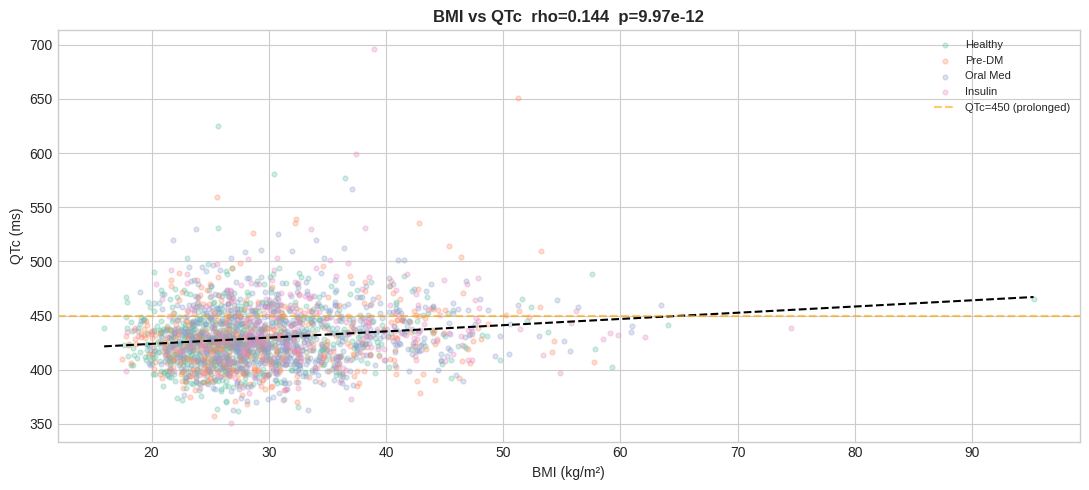

In [11]:
# ── 5b. Scatter: BMI vs QTc colored by study group ────────────────
if 'QTc' in df.columns:
    sub = df[['bmi', 'QTc', 'study_group_label']].dropna()
    fig, ax = plt.subplots(figsize=(11, 5))
    for grp in STUDY_GROUP_ORDER:
        s = sub[sub['study_group_label'] == grp]
        ax.scatter(s['bmi'], s['QTc'], alpha=0.3, s=12,
                   color=STUDY_GROUP_PAL[grp], label=grp)
    m, b, *_ = stats.linregress(sub['bmi'], sub['QTc'])
    xs = np.linspace(sub['bmi'].min(), sub['bmi'].max(), 100)
    ax.plot(xs, m*xs + b, 'k--', linewidth=1.5)
    ax.axhline(450, color='orange', linestyle='--', alpha=0.6, label='QTc=450 (prolonged)')
    rho, p = stats.spearmanr(sub['bmi'], sub['QTc'])
    ax.set_xlabel('BMI (kg/m²)'); ax.set_ylabel('QTc (ms)')
    ax.set_title(f'BMI vs QTc  rho={rho:.3f}  p={p:.2e}', fontweight='bold')
    ax.legend(fontsize=8)
    plt.tight_layout(); plt.show()

## Section 6: Activity × Weight / BP / ECG

In [12]:
# ── 6a. Spearman correlation matrix: activity vs physiological ──────
ACT_COL = 'average_daily_activity'

PHYS_TARGETS = [
    ('weight_kg',    'Weight (kg)'),
    ('bmi',          'BMI'),
    ('waist_cm',     'Waist Circumference (cm)'),
    ('systolic_bp',  'Systolic BP'),
    ('diastolic_bp', 'Diastolic BP'),
    ('pulse_bpm',    'Pulse (bpm)'),
    ('QTc',          'QTc (ms)'),
    ('Rate',         'ECG Rate (bpm)'),
]
PHYS_TARGETS = [(c, l) for c, l in PHYS_TARGETS if c in df.columns]

if ACT_COL in df.columns:
    print(f'=== Spearman: {ACT_COL} vs Physiological Metrics ===\n')
    corr_rows = []
    for col, label in PHYS_TARGETS:
        sub = df[[ACT_COL, col]].dropna()
        if len(sub) < 30:
            continue
        rho, p = stats.spearmanr(sub[ACT_COL], sub[col])
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        print(f'  {label:<25}: rho={rho:+.4f}  p={p:.4e}  n={len(sub):,}  {sig}')
        corr_rows.append({'metric': label, 'col': col, 'rho': round(rho, 4),
                          'p': round(p, 6), 'n': len(sub), 'sig': sig})

=== Spearman: average_daily_activity vs Physiological Metrics ===

  Weight (kg)              : rho=-0.0505  p=1.9827e-02  n=2,125  *
  BMI                      : rho=+0.0058  p=7.9091e-01  n=2,124  ns
  Waist Circumference (cm) : rho=-0.0860  p=7.3104e-05  n=2,120  ***
  Systolic BP              : rho=-0.0442  p=4.1501e-02  n=2,126  *
  Diastolic BP             : rho=+0.1154  p=9.6330e-08  n=2,126  ***
  Pulse (bpm)              : rho=+0.2570  p=2.0619e-33  n=2,126  ***
  QTc (ms)                 : rho=+0.0376  p=8.4331e-02  n=2,106  ns
  ECG Rate (bpm)           : rho=+0.2210  p=1.0237e-24  n=2,106  ***


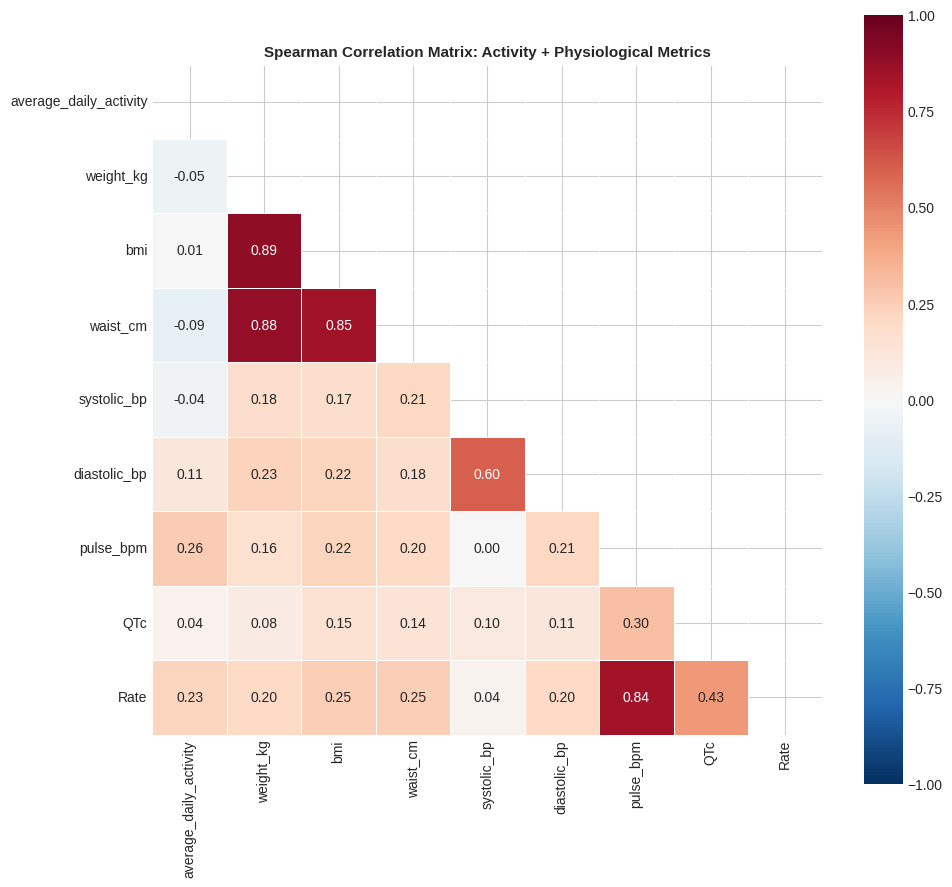

In [13]:
# ── 6b. Heatmap: correlation matrix ────────────────────────────────
all_cols = [ACT_COL] + [c for c, _ in PHYS_TARGETS if c in df.columns]
sub_mat  = df[all_cols].dropna(how='any')

if len(sub_mat) > 30:
    corr_matrix = sub_mat.corr(method='spearman')
    fig, ax = plt.subplots(figsize=(len(all_cols) * 0.9 + 2, len(all_cols) * 0.9 + 1))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
                cmap='RdBu_r', center=0, vmin=-1, vmax=1,
                square=True, linewidths=0.5, ax=ax)
    ax.set_title('Spearman Correlation Matrix: Activity + Physiological Metrics',
                 fontweight='bold', fontsize=11)
    plt.tight_layout()
    plt.show()

In [14]:
# ── 6c. Q1 vs Q4 activity: BP and QTc differences ─────────────────
if ACT_COL in df.columns:
    df_act = df.dropna(subset=[ACT_COL]).copy()
    df_act['activity_quartile'] = pd.qcut(
        df_act[ACT_COL], q=4,
        labels=['Q1 (Least Active)', 'Q2', 'Q3', 'Q4 (Most Active)'])

    q1 = df_act[df_act['activity_quartile'] == 'Q1 (Least Active)']
    q4 = df_act[df_act['activity_quartile'] == 'Q4 (Most Active)']

    print('=== Q1 (Least Active) vs Q4 (Most Active) — Physiological Outcomes ===\n')
    BONF_A = 0.05 / len(PHYS_TARGETS)
    print(f'Bonferroni alpha = {BONF_A:.4f}  ({len(PHYS_TARGETS)} outcomes)\n')
    print(f'{"Metric":<25}  {"Q1":>10}  {"Q4":>10}  {"diff":>8}  {"d":>7}  {"p":>8}  sig')
    print('-' * 80)

    for col, label in PHYS_TARGETS:
        if col not in df_act.columns:
            continue
        s1 = q1[col].dropna()
        s4 = q4[col].dropna()
        if len(s1) < 5 or len(s4) < 5:
            continue
        u, p = stats.mannwhitneyu(s1, s4, alternative='two-sided')
        d    = (s4.mean() - s1.mean()) / np.sqrt((s1.std(ddof=1)**2 + s4.std(ddof=1)**2) / 2)
        sig  = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
        print(f'{label:<25}  {s1.mean():>10.2f}  {s4.mean():>10.2f}  {s4.mean()-s1.mean():>+8.2f}  '
              f'{d:>+7.3f}  {p:>8.4f}  {sig}')

=== Q1 (Least Active) vs Q4 (Most Active) — Physiological Outcomes ===

Bonferroni alpha = 0.0063  (8 outcomes)

Metric                             Q1          Q4      diff        d         p  sig
--------------------------------------------------------------------------------
Weight (kg)                     85.61       82.94     -2.67   -0.121    0.0178  *
BMI                             30.39       30.39     +0.00   +0.000    0.9487  ns
Waist Circumference (cm)       104.10      100.18     -3.92   -0.221    0.0001  ***
Systolic BP                    128.95      127.05     -1.90   -0.113    0.0869  ns
Diastolic BP                    75.23       78.24     +3.01   +0.298    0.0000  ***
Pulse (bpm)                     69.40       77.20     +7.81   +0.662    0.0000  ***
QTc (ms)                       432.47      431.67     -0.79   -0.028    0.8473  ns
ECG Rate (bpm)                  65.26       71.34     +6.08   +0.555    0.0000  ***


## Section 7: Multivariable OLS Summary

In [15]:
# ── 7. OLS: mean_glucose ~ BMI + activity + systolic_BP + study_group
import statsmodels.formula.api as smf

reg_predictors = ['bmi', ACT_COL, 'systolic_bp', 'study_group_code']
reg_predictors = [c for c in reg_predictors if c in df.columns]

reg_df = df[['mean_glucose'] + reg_predictors].dropna()
print(f'Regression dataset: n={len(reg_df)}')

formula = 'mean_glucose ~ ' + ' + '.join(reg_predictors)
model   = smf.ols(formula, data=reg_df).fit()

reg_table = pd.DataFrame({
    'predictor': model.params.index,
    'coef':      model.params.round(4).values,
    'se':        model.bse.round(4).values,
    't':         model.tvalues.round(3).values,
    'p':         model.pvalues.round(5).values,
})
reg_table['sig'] = reg_table['p'].apply(
    lambda p: '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns')))

print(f'\nModel R² = {model.rsquared:.4f}  Adj-R² = {model.rsquared_adj:.4f}')
print(f'F({model.df_model:.0f}, {model.df_resid:.0f}) = {model.fvalue:.2f}  p = {model.f_pvalue:.2e}\n')
print(reg_table.to_string(index=False))

Regression dataset: n=2122

Model R² = 0.2865  Adj-R² = 0.2852
F(4, 2117) = 212.52  p = 2.00e-153

             predictor   coef    se      t     p sig
             Intercept 83.156 5.225 15.915 0.000 ***
                   bmi  0.049 0.088  0.557 0.577  ns
average_daily_activity  0.000 0.000  1.003 0.316  ns
           systolic_bp  0.225 0.037  6.007 0.000 ***
      study_group_code 17.204 0.630 27.320 0.000 ***


In [16]:
# ── Summary table & export ─────────────────────────────────────────
summary_rows = []
for grp in ['All'] + STUDY_GROUP_ORDER:
    sub = df if grp == 'All' else df[df['study_group_label'] == grp]
    row = {'study_group': grp, 'n': len(sub)}
    for col, _ in PHYS_TARGETS + [(ACT_COL, 'Activity')]:
        if col in sub.columns:
            row[f'{col}_mean'] = round(sub[col].mean(), 3)
            row[f'{col}_sd']   = round(sub[col].std(ddof=1), 3)
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

summary_df.to_csv(out_dir / '23_bmi_activity_physiological_summary.csv', index=False)
reg_table.to_csv(out_dir / '23_regression_table.csv', index=False)
print('\nSaved 23_bmi_activity_physiological_summary.csv')
print('Saved 23_regression_table.csv')

study_group    n  weight_kg_mean  weight_kg_sd  bmi_mean  bmi_sd  waist_cm_mean  waist_cm_sd  systolic_bp_mean  systolic_bp_sd  diastolic_bp_mean  diastolic_bp_sd  pulse_bpm_mean  pulse_bpm_sd  QTc_mean  QTc_sd  Rate_mean  Rate_sd  average_daily_activity_mean  average_daily_activity_sd
        All 2251          83.856        22.355    30.106   7.472        101.124       17.664           128.513          17.106             76.897           10.168          71.412        11.831   429.732  28.038     66.422   10.962                     6167.469                   3840.414
    Healthy  762          78.550        20.520    28.284   7.008         95.607       16.369           127.397          16.893             76.844            9.978          69.514        11.315   427.438  26.026     63.822   10.218                     6224.686                   3577.581
     Pre-DM  554          81.886        21.860    29.695   7.252         99.066       17.176           128.816          17.203             

## Key Findings

### BMI Distribution by Study Group (Section 2)

Overall cohort: mean BMI = 30.1 (SD 7.5), range 15.9–95.2. Obesity (BMI ≥30) prevalence escalates monotonically with disease severity:

| Study Group | Mean BMI | SD | Obesity Prevalence |
|-------------|----------|----|--------------------|
| Healthy | 28.3 | 7.0 | 25.3% |
| Pre-DM | 29.7 | 7.3 | 38.2% |
| Oral Med | 31.2 | 7.1 | 48.4% |
| Insulin | 33.5 | 8.6 | 53.1% |

Kruskal-Wallis: H significant, p<0.0001*** — BMI is strongly stratified by diabetes severity. This mirrors the comorbidity burden gradient seen in NB24.

---

### BMI × Activity (Section 3)

- Overall Spearman: rho=+0.006, p=0.791 — **no linear relationship**
- Within-group: all non-significant across all four study groups

**Interpretation**: BMI and wearable-measured activity are essentially orthogonal in this cohort. High-BMI individuals are not necessarily less active by Garmin step count. This may reflect that (a) the activity metric captures step frequency rather than intensity, (b) heavier individuals may take more steps in daily tasks, or (c) wearable wear-time patterns differ across BMI groups. This null finding is important: **do not interpret activity quartile differences as BMI-mediated.**

---

### BMI × Blood Pressure (Section 4)

| Study Group | Systolic BP rho | Diastolic BP rho | Pulse rho |
|-------------|-----------------|------------------|-----------|
| All | +0.166*** | +0.216*** | +0.224*** |
| Healthy | +0.209*** | +0.221*** | +0.207*** |
| Pre-DM | +0.176*** | +0.270*** | +0.160*** |
| Oral Med | +0.136*** | +0.255*** | +0.193*** |
| Insulin | +0.039 ns | +0.116 ns | +0.094 ns |

BMI-BP associations are consistent and significant across Healthy, Pre-DM, and Oral Med groups, but attenuate to non-significance within the Insulin group. This attenuation likely reflects that Insulin patients are on more intensive antihypertensive therapy, compressing the BP distribution and masking the underlying BMI relationship.

---

### BMI × ECG (QTc, Rate) (Section 5)

- **QTc**: rho=+0.144, p<0.0001*** (overall). Pattern holds in Healthy (rho=+0.129***), Pre-DM (rho=+0.144***), and Oral Med (rho=+0.084*), but attenuates to ns in Insulin (rho=+0.068, p=0.285). Higher BMI is associated with mild QTc prolongation — consistent with literature on obesity-related cardiac remodeling.
- **ECG Heart Rate**: rho=+0.248, p<0.0001*** — stronger association than QTc, consistent across all groups except Insulin (ns).
- **QT Interval** (uncorrected): rho=−0.140, p<0.0001*** — inverse of QTc, as expected after rate-correction.

The QTc finding is clinically relevant: obese patients already at elevated cardiovascular risk from diabetes may have additive QTc prolongation risk, particularly relevant for medication selection (drugs that further prolong QTc).

---

### Activity × Physiological Metrics (Section 6)

| Metric | Activity rho | Q1 Mean | Q4 Mean | Q1 vs Q4 diff | p |
|--------|-------------|---------|---------|---------------|---|
| Weight (kg) | −0.051* | 85.6 | 82.9 | −2.67 kg | 0.018* |
| Waist circ. (cm) | −0.086*** | 104.1 | 100.2 | −3.92 cm | <0.001*** |
| Systolic BP | −0.044* | 129.0 | 127.1 | −1.9 mmHg | 0.087 ns |
| Diastolic BP | +0.115*** | 75.2 | 78.2 | +3.0 mmHg | <0.001*** |
| Pulse (bpm) | +0.257*** | 69.4 | 77.2 | +7.8 bpm | <0.001*** |
| QTc (ms) | +0.038 ns | 432.5 | 431.7 | −0.8 ms | 0.847 ns |
| ECG Rate (bpm) | +0.221*** | 65.3 | 71.3 | +6.1 bpm | <0.001*** |
| BMI | +0.006 ns | — | — | — | ns |

Key observations:
- More active participants have significantly smaller waist circumference (−3.92 cm, p<0.001) — the strongest body composition association with activity.
- The apparent paradox of higher diastolic BP in the most active quartile (Q4) is likely a confound of resting heart rate: more active individuals have higher device-measured heart rates captured during activity periods, and diastolic BP correlates with HR in this context.
- QTc is not significantly different between activity quartiles — physical activity does not modify QTc in this cohort.

---

### Multivariable OLS — Mean Glucose (Section 7)

Model: `mean_glucose ~ BMI + activity + systolic_BP + study_group_code`
- **R² = 0.287**, n=2,122 — the model explains 28.7% of variance in mean glucose
- **Study group code: β=+17.20, p<0.0001*** — by far the dominant predictor; each step up in disease severity adds ~17 mg/dL to mean glucose**
- Systolic BP: β=+0.225, p<0.0001*** — independent predictor after controlling for group
- BMI: β=+0.049, p=0.577 ns — not independently significant after controlling for disease severity and BP
- Activity: β≈0, p=0.316 ns — not independently significant

**Interpretation**: Disease severity (study group assignment) accounts for the majority of variance in mean glucose. BMI and physical activity do not independently predict glucose once disease severity is controlled — they are absorbed by the group variable. Systolic BP is the only physiological metric with an independent contribution, consistent with shared cardiovascular-metabolic pathways.